# AI Sales Analysis with Groq
This notebook downloads a public sales dataset, performs analysis with Pandas, visualizes results, and asks a Groq LLM for business insights.

## 1. Install dependencies
Run if needed.

In [ ]:
%pip install -q pandas matplotlib groq

## 2. Imports

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from groq import Groq

## 3. Download Dataset

In [2]:
url="supermarket-sales.csv"
df=pd.read_csv(url)
print(df.shape)
df.head()

(1000, 17)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,Cost of goods sold,Gross margin percentage,Gross income,Customer stratification rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


## 4. Exploratory Data Analysis

In [3]:
display(df.describe(include='all'))
display(df.isna().sum())

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,Cost of goods sold,Gross margin percentage,Gross income,Customer stratification rating
count,1000,1000,1000,1000,1000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000,1000,1000.00000,1000.000000,1000.000000,1000.00000
unique,1000,3,3,2,2,6,NaN,NaN,NaN,NaN,89,506,3,NaN,NaN,NaN,NaN
top,750-67-8428,A,Yangon,Member,Female,Fashion accessories,NaN,NaN,NaN,NaN,2/7/2019,19:48,Ewallet,NaN,NaN,NaN,NaN
freq,1,340,340,501,501,178,NaN,NaN,NaN,NaN,20,7,345,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,55.672130,5.510000,15.379369,322.966749,NaN,NaN,NaN,307.58738,4.761905,15.379369,6.97270
std,NaN,NaN,NaN,NaN,NaN,NaN,26.494628,2.923431,11.708825,245.885335,NaN,NaN,NaN,234.17651,0.000000,11.708825,1.71858
min,NaN,NaN,NaN,NaN,NaN,NaN,10.080000,1.000000,0.508500,10.678500,NaN,NaN,NaN,10.17000,4.761905,0.508500,4.00000
25%,NaN,NaN,NaN,NaN,NaN,NaN,32.875000,3.000000,5.924875,124.422375,NaN,NaN,NaN,118.49750,4.761905,5.924875,5.50000
50%,NaN,NaN,NaN,NaN,NaN,NaN,55.230000,5.000000,12.088000,253.848000,NaN,NaN,NaN,241.76000,4.761905,12.088000,7.00000
75%,NaN,NaN,NaN,NaN,NaN,NaN,77.935000,8.000000,22.445250,471.350250,NaN,NaN,NaN,448.90500,4.761905,22.445250,8.50000


Invoice ID                        0
Branch                            0
City                              0
Customer type                     0
Gender                            0
Product line                      0
Unit price                        0
Quantity                          0
Tax 5%                            0
Total                             0
Date                              0
Time                              0
Payment                           0
Cost of goods sold                0
Gross margin percentage           0
Gross income                      0
Customer stratification rating    0
dtype: int64

## 5. KPI Calculations

In [4]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'Cost of goods sold', 'Gross margin percentage',
       'Gross income', 'Customer stratification rating'],
      dtype='str')

In [5]:
total_sales=df["Total"].sum()
avg_sale=df["Total"].mean()
city_sales=df.groupby("City")["Total"].sum().sort_values(ascending=False)
product_sales=df.groupby("Product line")["Total"].sum().sort_values(ascending=False)
payment_sales=df.groupby("Payment")["Total"].sum().sort_values(ascending=False)

print("Total Sales:",round(total_sales,2))
print("Average Sale:",round(avg_sale,2))
display(city_sales)
display(product_sales)
display(payment_sales)

Total Sales: 322966.75
Average Sale: 322.97


City
Naypyitaw    110568.7065
Yangon       106200.3705
Mandalay     106197.6720
Name: Total, dtype: float64

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Total, dtype: float64

Payment
Cash           112206.570
Ewallet        109993.107
Credit card    100767.072
Name: Total, dtype: float64

## 6. Visualization

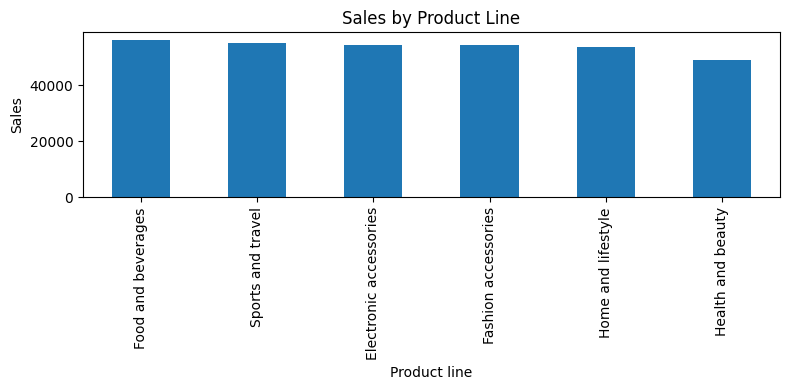

In [6]:
plt.figure(figsize=(8,4))
product_sales.plot(kind="bar")
plt.title("Sales by Product Line")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

## 7. AI Analysis using Groq

In [7]:


summary=f'''
Total Sales: {total_sales:.2f}
Average Sale: {avg_sale:.2f}

Sales by City:
{city_sales.to_string()}

Sales by Product:
{product_sales.to_string()}

Payment Modes:
{payment_sales.to_string()}
'''

print(summary)



Total Sales: 322966.75
Average Sale: 322.97

Sales by City:
City
Naypyitaw    110568.7065
Yangon       106200.3705
Mandalay     106197.6720

Sales by Product:
Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390

Payment Modes:
Payment
Cash           112206.570
Ewallet        109993.107
Credit card    100767.072



In [8]:
with open(r"C:\mindful-ai\samsung\samsung-ai\key-vault\groq-api.key") as f:
    api_key = f.read().strip()


client=Groq(api_key=api_key)


In [9]:

response=client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    temperature=0.3,
    messages=[
        {"role":"system","content":"You are a senior business analyst."},
        {"role":"user","content":f'''Analyze this supermarket sales summary and provide:
1. Executive Summary
2. Key Trends
3. Best Performing Categories
4. Weak Areas
5. Customer Behaviour
6. Five Actionable Recommendations

{summary}'''}
    ]
)

print(response.choices[0].message.content)

**1. Executive Summary**
The supermarket sales summary reveals a total sales figure of $322,966.75, with an average sale of $322.97. The sales are distributed across three cities, with Naypyitaw, Yangon, and Mandalay contributing significantly to the total sales. The product lines with the highest sales are food and beverages, sports and travel, electronic accessories, fashion accessories, and home and lifestyle. The payment modes used by customers are primarily cash, e-wallet, and credit card.

**2. Key Trends**
- The sales are evenly distributed across the three cities, indicating a strong presence in each location.
- Food and beverages, sports and travel, and electronic accessories are the top-performing product lines, suggesting a high demand for these categories.
- Cash, e-wallet, and credit card are the preferred payment modes, with a slight inclination towards cash transactions.
- The average sale amount is $322.97, indicating a moderate to high-value transaction per customer.



## 8. Suggested Exercises
- Change the model.
- Ask different business questions.
- Create monthly and city-wise charts.
- Export results to Excel/PDF.

#### Use the executive summary and ask two business questions such as: 
#### "How to improve the weak areas? Give top two methods and explain how to organize and execute it"